In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"Cleaned_data.csv")
print(df.head())
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

              datetime  Global_active_power  Global_reactive_power  \
0  2006-12-18 17:00:00             2.154900               0.097800   
1  2006-12-18 18:00:00             2.402533               0.079100   
2  2006-12-18 19:00:00             2.614500               0.200767   
3  2006-12-18 20:00:00             3.050567               0.120367   
4  2006-12-18 21:00:00             2.169733               0.071733   

      Voltage  Global_intensity  Sub_metering_1  Sub_metering_2  \
0  238.729167          8.993333             0.0        0.333333   
1  236.668500         10.083333             0.0        0.250000   
2  235.329167         11.190000             0.0        9.100000   
3  234.524333         13.046667             0.0        0.500000   
4  237.590833          9.240000             0.0        0.000000   

   Sub_metering_3  hour  day  month  weekday     lag_1     lag_2    lag_24  \
0       17.450000    17   18     12        0  1.949300  1.784300  3.406767   
1       16.916667   

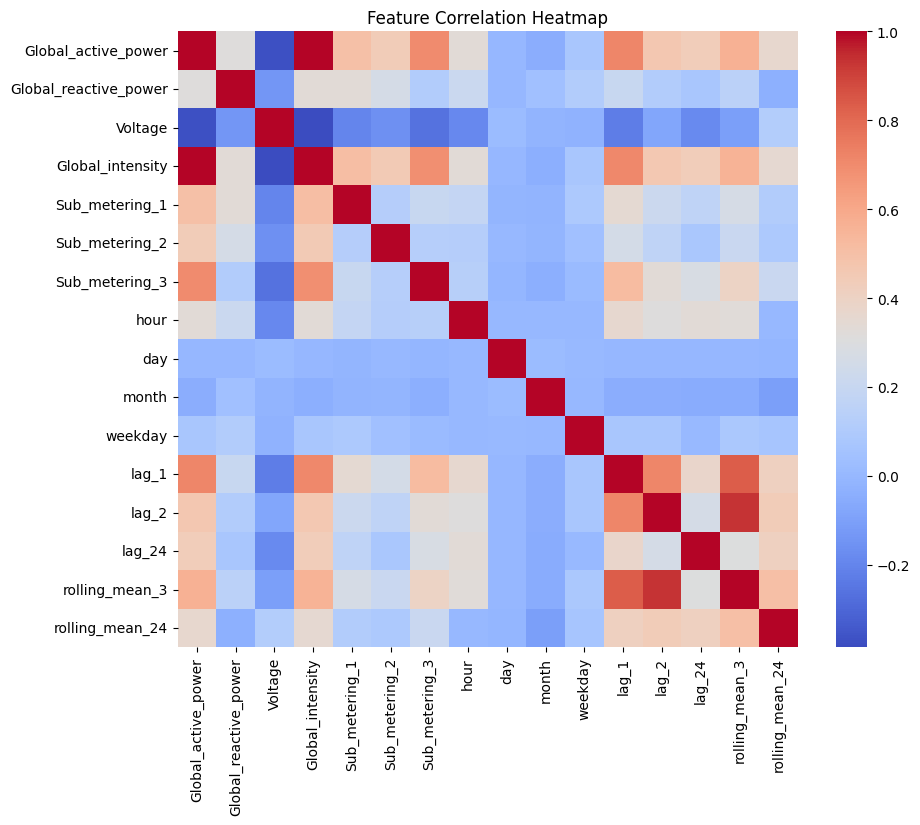

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [21]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Global_active_power'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -14.20696298204236
p-value: 1.7480750011325128e-26


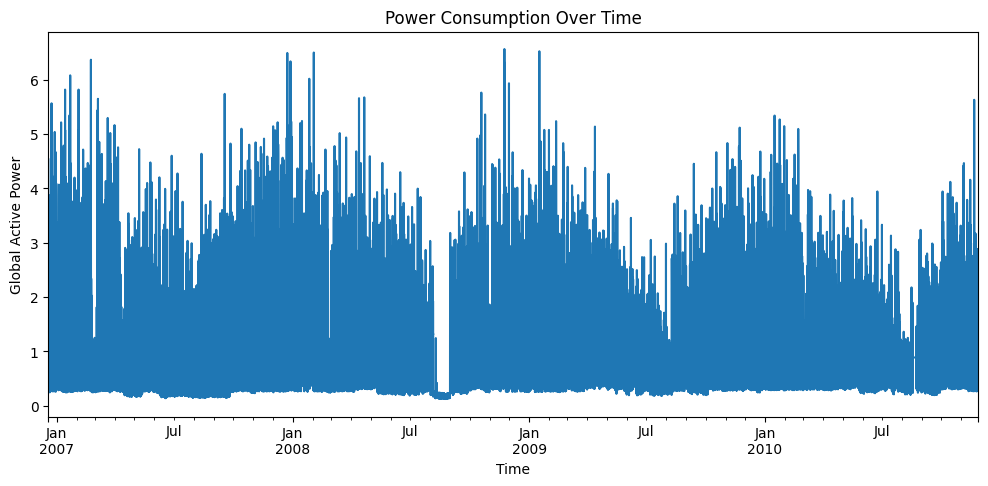

In [22]:
# Plot the Global_active_power over time 
df['Global_active_power'].plot(figsize=(12,5))
plt.title("Power Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.show()

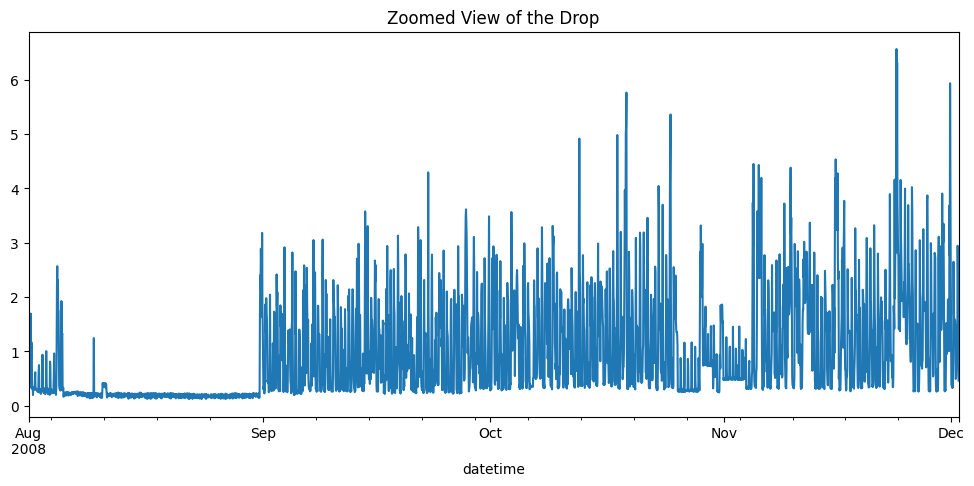

In [23]:
# Slicing the data to see the "gap" period
gap_period = df.loc['2008-08-01':'2008-12-01']

# Plotting the zoom-in to see the behavior
gap_period['Global_active_power'].plot(figsize=(12,5))
plt.title("Zoomed View of the Drop")
plt.show()

In [24]:
gap = df.loc['2008-08-01':'2008-09-01']

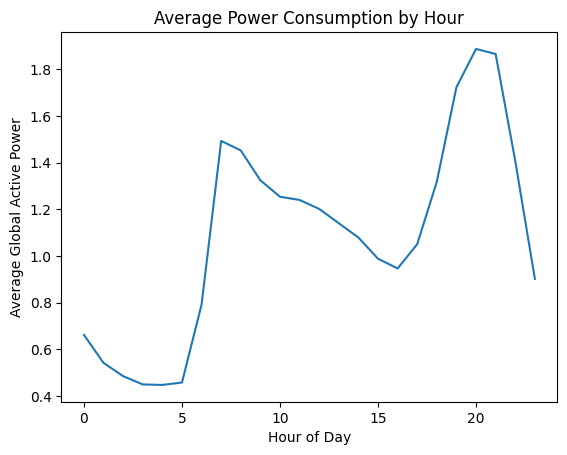

In [25]:
# Plot average power consumption by hour of the day (Daily pattern)
df.groupby('hour')['Global_active_power'].mean().plot()
plt.title("Average Power Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power")
plt.show()

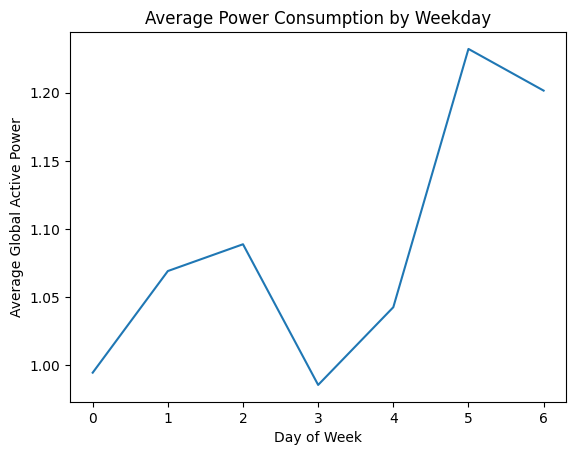

In [26]:
# Plot average power consumption by day of the week (Weekly pattern)
df.groupby('weekday')['Global_active_power'].mean().plot()
plt.title("Average Power Consumption by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Average Global Active Power")
plt.show()


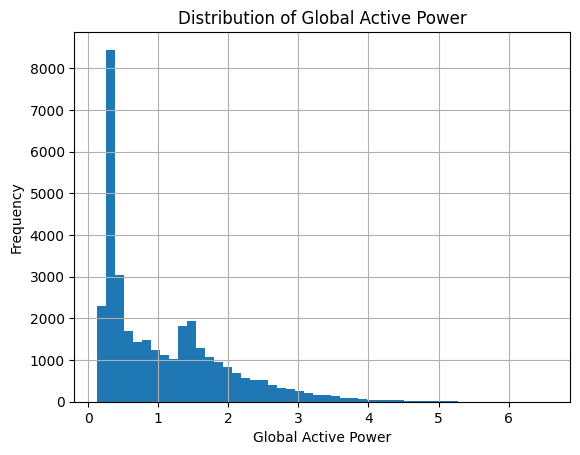

In [27]:
# Plot the distribution of Global_active_power
df['Global_active_power'].hist(bins=50)
plt.title("Distribution of Global Active Power")
plt.xlabel("Global Active Power")
plt.ylabel("Frequency")
plt.show()

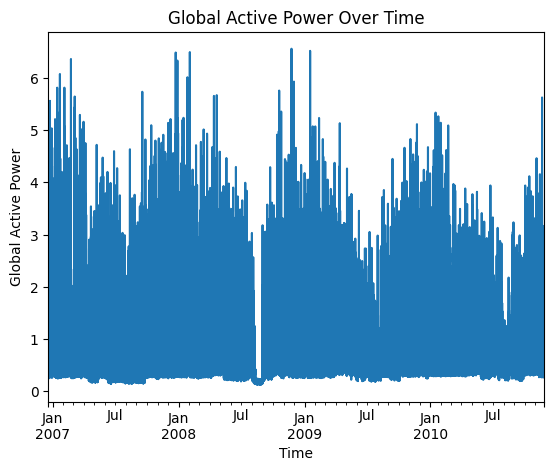

In [28]:
# Plot the time series of Global_active_power to identify trends and seasonality
df['Global_active_power'].plot()
plt.title("Global Active Power Over Time")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.show()

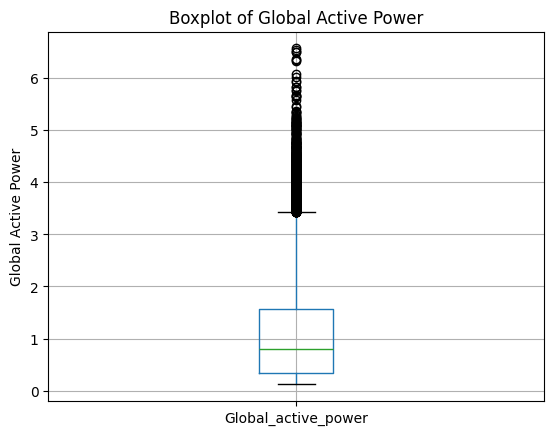

In [29]:
# Determine Outliers using boxplot
df.boxplot(column='Global_active_power')
plt.title("Boxplot of Global Active Power")
plt.ylabel("Global Active Power")
plt.show()


In [30]:
df.shape

(34541, 16)